In [1]:
import os
import pickle
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams, cycler
from matplotlib.cm import ScalarMappable
import seaborn as sns
import tensorflow as tf
from scipy.stats import pearsonr, gaussian_kde, ecdf
from sklearn.decomposition import PCA
import sys
sys.path.append(os.path.join('c:\\', *os.getcwd().split('\\')[1:-1]))
from sgcc11 import *

In [2]:
plt.rcParams['figure.dpi'] = 300
fontsize = 8
linewidth = 0.5

In [3]:
X = tf.convert_to_tensor([0.02,0.04,0.08,0.1,0.12,0.16,0.2,0.24,0.28,0.32], dtype = tf.float32)

In [4]:
param_bounds = {
    "fts": [-200, 200],
    "t": [40, 150],
    "ampc": [0.01, 0.1],
    'ampm': [0,3],
    "ampg": [0.1, 4],
    "ampw": [0.01,0.1],
    "d": [10, 40],
    "inh_d": [0, 40],
    "inh_w": [0, 3],
}

In [5]:
model = SGCCircuit(param_bounds)

In [6]:
optimized_model_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'sgcc_full_population_4_27_26_2.pkl')
with open(optimized_model_file, 'rb') as f:
    model_state = pickle.load(f)

In [7]:
model.load_saved_parameters(model_state['final_epoch_params'])

In [8]:
param_history = model_state['param_history']

In [9]:
loss_decay = model_state['loss_decay']
last_epoch = loss_decay[-1]
best = np.where(last_epoch == last_epoch.min())[0][0]
print(f"Index of best parameters: {best}, loss = {last_epoch[best]}")

Index of best parameters: 2, loss = 0.00327301025390625


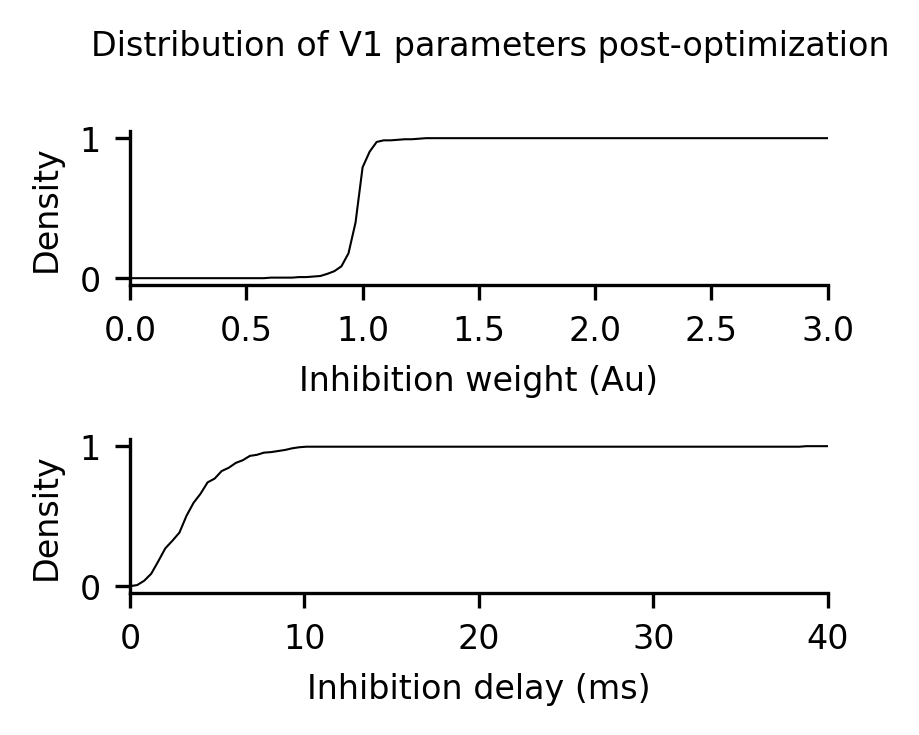

In [ ]:
fig, ax = plt.subplots(2,1, figsize = (3,2))

for i in range(2):
    i_ = np.abs(i-1)

    x = np.linspace(
        list(param_bounds.values())[-1-i][0],
        list(param_bounds.values())[-1-i][1],
        100
    )
    data = param_history['V1_params'][best, -1,:,0,i_,0,0]
    kde = ecdf(data).cdf
    y = kde.evaluate(x)

    ax[i].plot(x,y, linewidth = linewidth, color = 'black')
    ax[i].set_xlim(
        list(param_bounds.values())[-1-i][0],
        list(param_bounds.values())[-1-i][1]
    )
    ax[i].set_ylabel("Density", fontsize = fontsize)
    ax[i].tick_params(labelsize = fontsize)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)

ax[0].set_xlabel('Inhibition weight (Au)', fontsize = fontsize)
ax[1].set_xlabel('Inhibition delay (ms)', fontsize = fontsize)
fig.subplots_adjust(hspace=1)
plt.suptitle("Distribution of V1 parameters post-optimization", fontsize = fontsize, x = 0.525, y = 1.05)


# figname = 'v1_parameter_dist_single_unit_opt_rds.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

Text(0.525, 0.925, 'Distribution of dLGN parameters post-optimization')

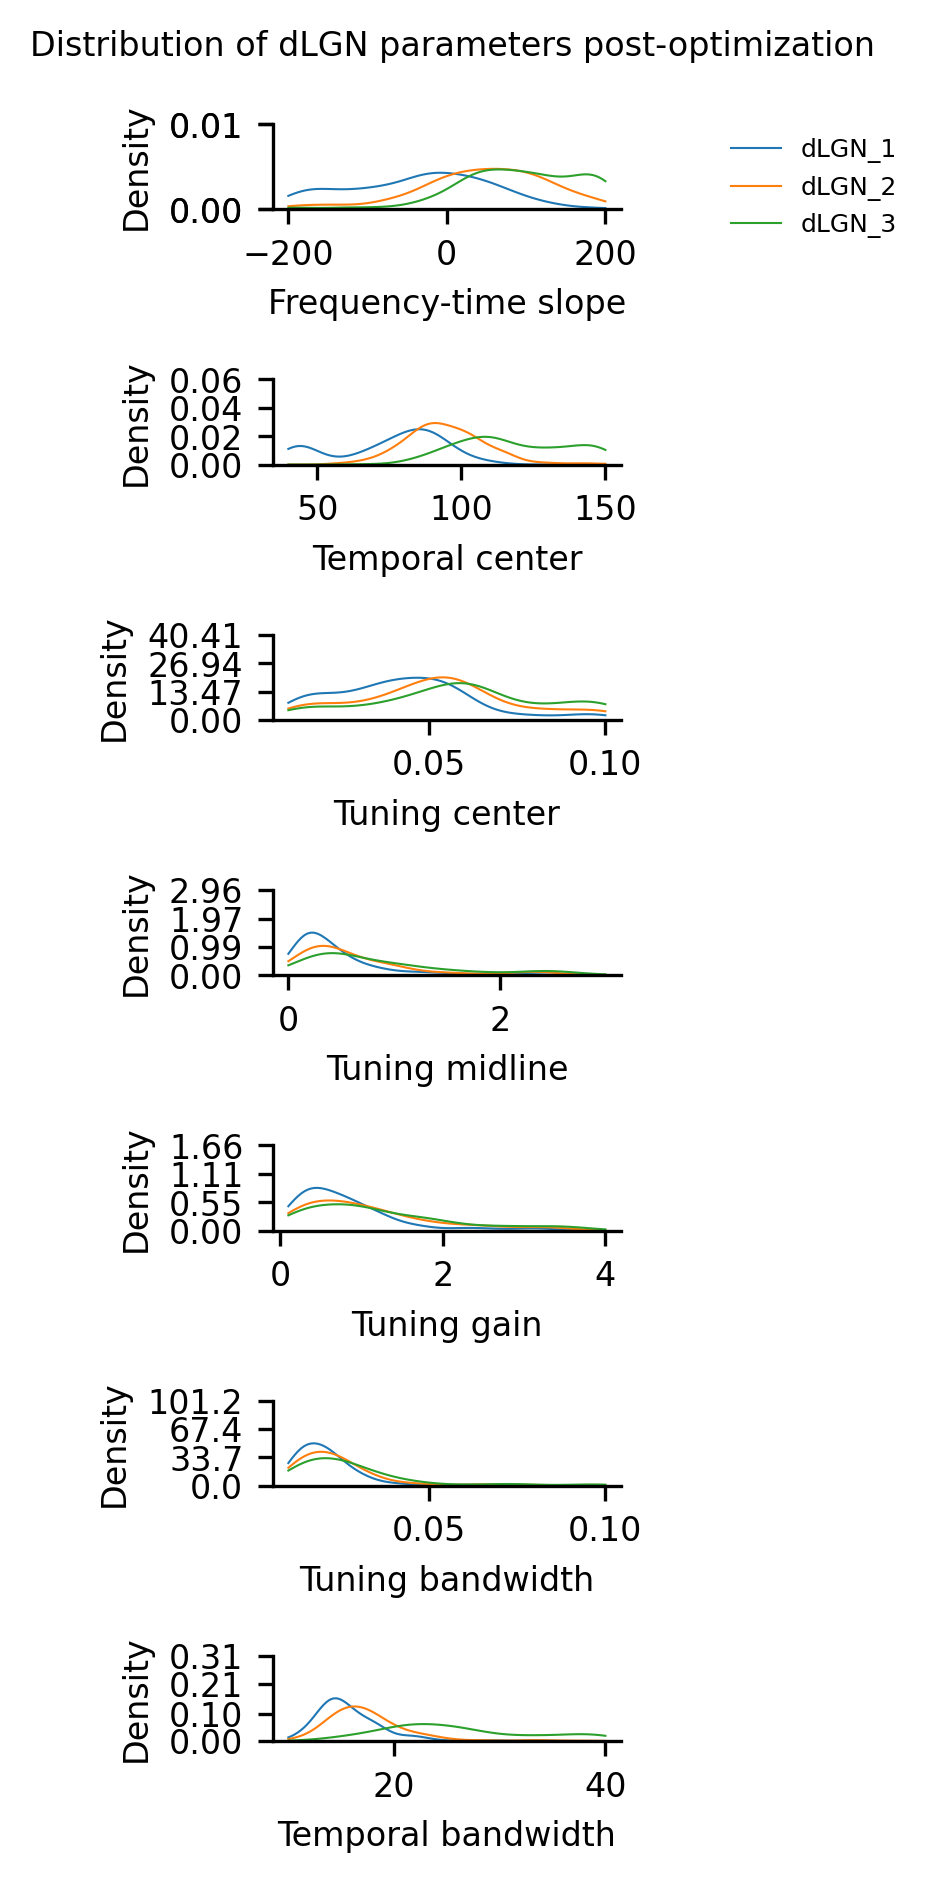

In [15]:
cmap = plt.get_cmap('tab10') 
rcParams['axes.prop_cycle'] = cycler(color=cmap(np.linspace(0, 1, 10)))
fig, ax = plt.subplots(7,1, figsize = (1.5, 7))

param_labels = [
    'Frequency-time slope',
    'Temporal center',
    'Tuning center',
    'Tuning midline',
    'Tuning gain',
    'Tuning bandwidth',
    'Temporal bandwidth'
]

n_lgn = 3
neuron_labels = [f'dLGN_{i+1}' for i in range(n_lgn)]


for row in range(7):
    ymax = []
    for i in range(n_lgn):
        data = param_history['dLGN_params'][best,-1,:,i,row,0,0]
        x = np.linspace(
            list(param_bounds.values())[:7][row][0],
            list(param_bounds.values())[:7][row][1], 
            100
        )
        kde = gaussian_kde(data)
        y = kde(x)

        ymax.append(y.max())
        
        ax[row].plot(x, y, label = neuron_labels[i], linewidth = linewidth)
        ax[row].set_xlabel(param_labels[row], fontsize = fontsize)

    ax[row].set_ylabel("Density", fontsize = fontsize)
    ax[row].set_ylim(0, np.max(ymax)+np.max(ymax)*0.25)
    ax[row].set_yticks(np.linspace(0, np.max(ymax)+np.max(ymax), 4).round(2))
    ax[row].tick_params(labelsize = fontsize)
    ax[row].spines['top'].set_visible(False)
    ax[row].spines['right'].set_visible(False)

fig.subplots_adjust(hspace = 2)
ax[0].legend(fontsize = 6, bbox_to_anchor = (1.25,1.1), frameon = False)
plt.suptitle("Distribution of dLGN parameters post-optimization", fontsize = fontsize, x = 0.525, y = 0.925)

# figname = 'separate_lgn_parameter_dist_single_unit_opt_rds.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

Text(0.525, 0.95, 'Distribution of dLGN parameters post-optimization\n(summed across input units)')

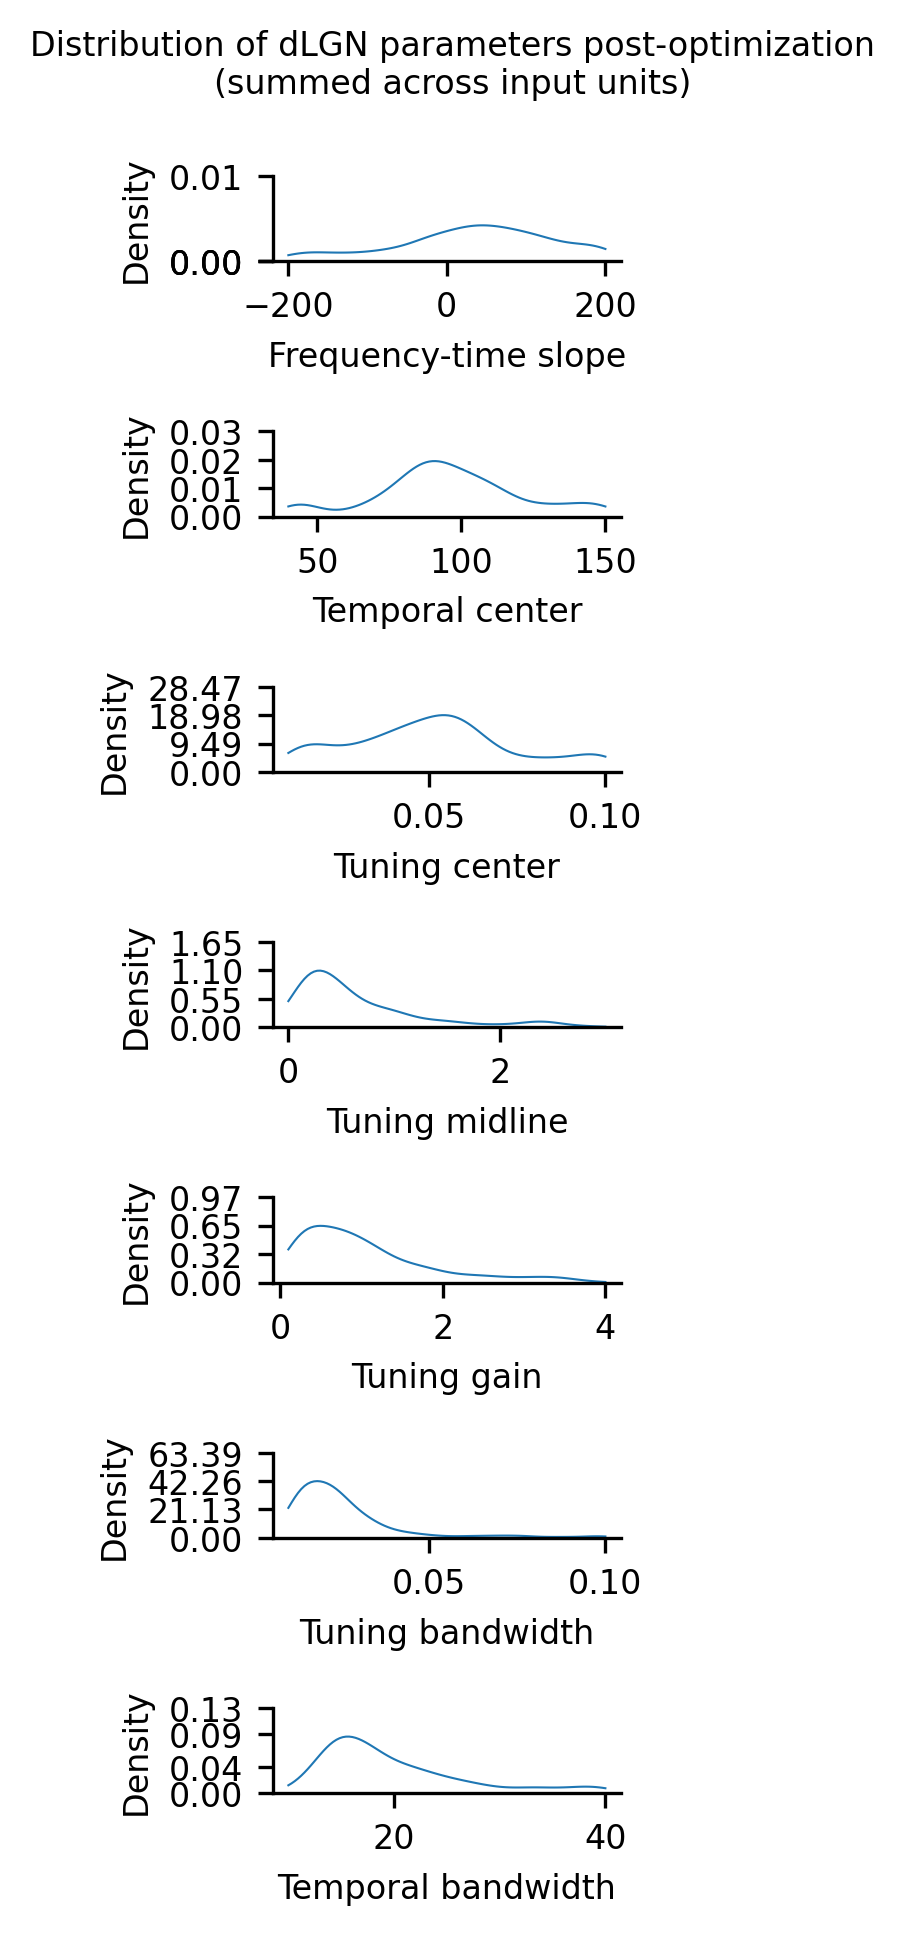

In [16]:
cmap = plt.get_cmap('tab10') 
rcParams['axes.prop_cycle'] = cycler(color=cmap(np.linspace(0, 1, 10)))
fig, ax = plt.subplots(7,1, figsize = (1.5, 7))

param_labels = [
    'Frequency-time slope',
    'Temporal center',
    'Tuning center',
    'Tuning midline',
    'Tuning gain',
    'Tuning bandwidth',
    'Temporal bandwidth'
]

n_lgn = 3
neuron_labels = [f'dLGN_{i+1}' for i in range(n_lgn)]


for row in range(7):
    ymax = []
    
    data = param_history['dLGN_params'][best,-1,:,:,row,0,0].flatten()

    x = np.linspace(
        list(param_bounds.values())[:7][row][0],
        list(param_bounds.values())[:7][row][1], 
        100
    )
    kde = gaussian_kde(data)
    y = kde(x)

    ymax.append(y.max())
    
    ax[row].plot(x, y, label = neuron_labels[i], linewidth = linewidth)
    ax[row].set_xlabel(param_labels[row], fontsize = fontsize)

    ax[row].set_ylabel("Density", fontsize = fontsize)
    ax[row].set_ylim(0, np.max(ymax)+np.max(ymax)*0.25)
    ax[row].set_yticks(np.linspace(0, np.max(ymax)+np.max(ymax)*0.5, 4).round(2))
    ax[row].tick_params(labelsize = fontsize)
    ax[row].spines['top'].set_visible(False)
    ax[row].spines['right'].set_visible(False)

fig.subplots_adjust(hspace = 2)
plt.suptitle("Distribution of dLGN parameters post-optimization\n(summed across input units)", fontsize = fontsize, x = 0.525, y = 0.95)

Text(0.525, 0.95, 'Distribution of dLGN parameters post-optimization\n(summed across input units)')

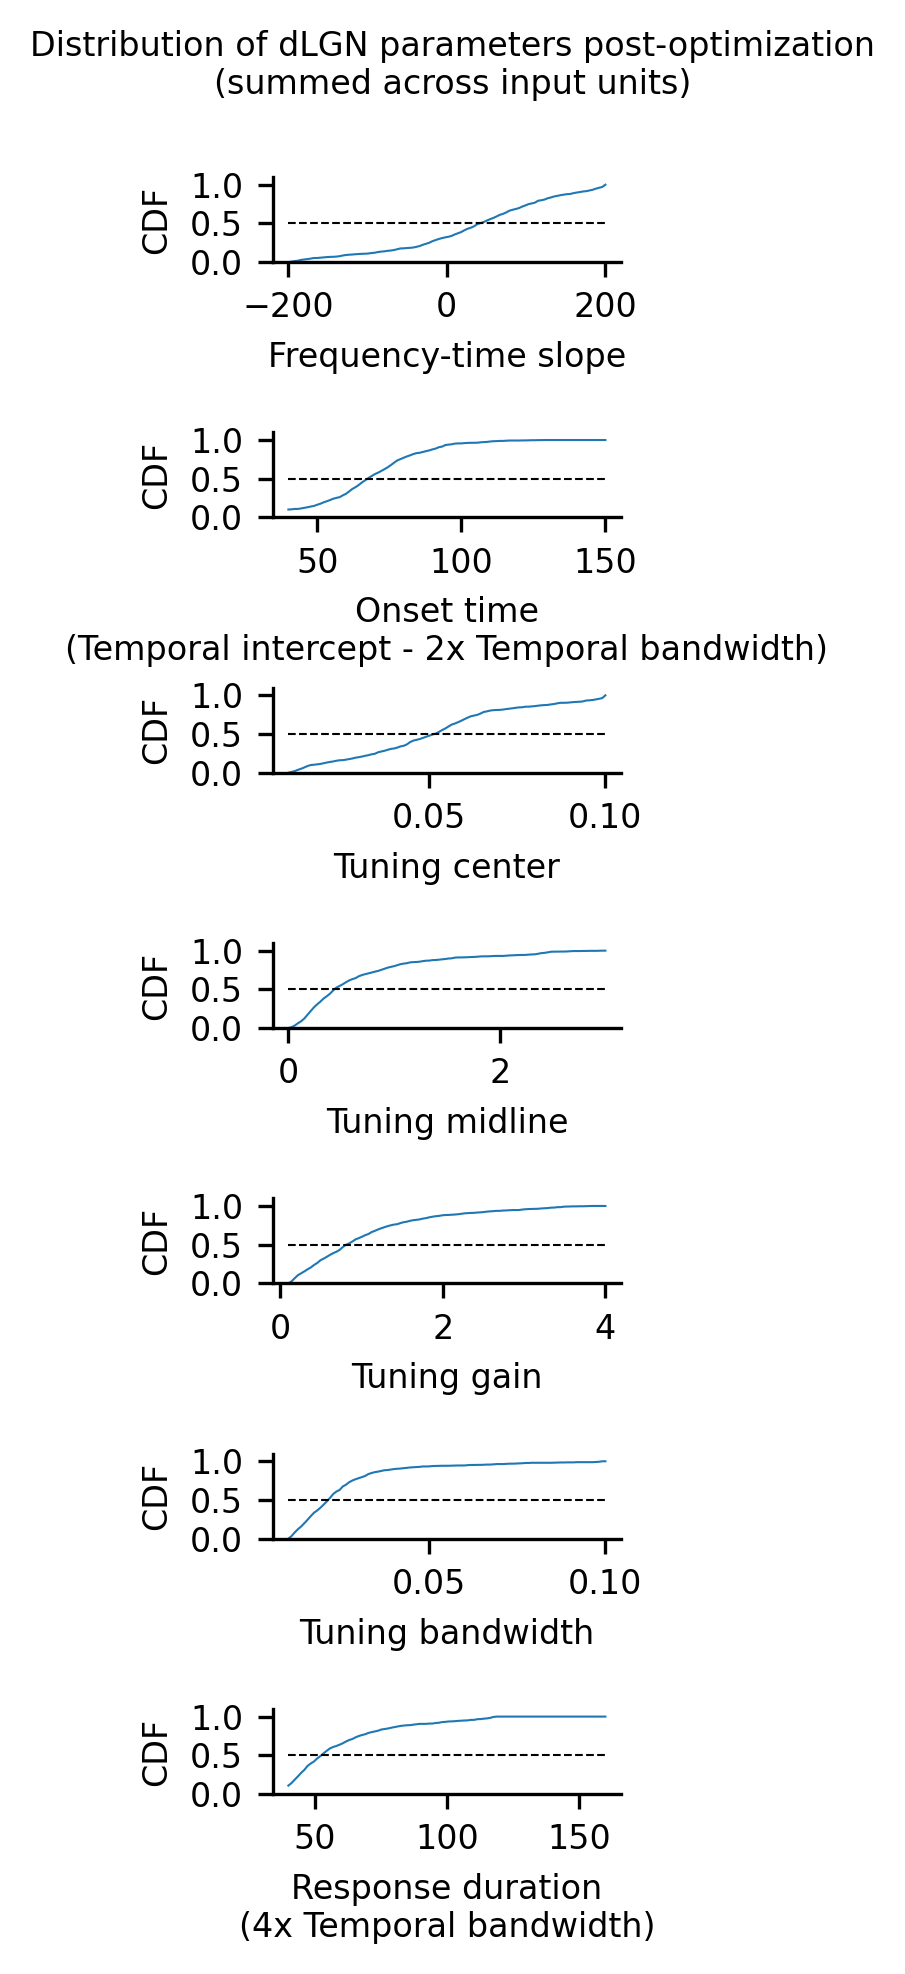

In [17]:
cmap = plt.get_cmap('tab10') 
rcParams['axes.prop_cycle'] = cycler(color=cmap(np.linspace(0, 1, 10)))
fig, ax = plt.subplots(7,1, figsize = (1.5, 7))

param_labels = [
    'Frequency-time slope',
    'Onset time\n(Temporal intercept - 2x Temporal bandwidth)',
    'Tuning center',
    'Tuning midline',
    'Tuning gain',
    'Tuning bandwidth',
    'Response duration\n(4x Temporal bandwidth)'
]

n_lgn = 3
neuron_labels = [f'dLGN_{i+1}' for i in range(n_lgn)]

temporal = ['Frequency-time slope', 'Onset time\n(Temporal intercept - 2x Temporal bandwidth)', 'Response duration\n(4x Temporal bandwidth)']
tpdist = []
for row in range(7):
    ymax = []
    if row == 1:
        data = (param_history['dLGN_params'][best,-1,:,:,row,0,0].flatten() 
                - (param_history['dLGN_params'][best,-1,:,:,-1,0,0]).flatten()*1.48)#np.random.uniform(1,2, size = 777))
    else:
        data = param_history['dLGN_params'][best,-1,:,:,row,0,0].flatten()

    if row == 6:
        data = param_history['dLGN_params'][best,-1,:,:,row,0,0].flatten()*2.96#np.random.uniform(3,4, size = 777)
        x = np.linspace(
            list(param_bounds.values())[:7][row][0]*4,
            list(param_bounds.values())[:7][row][1]*4, 
            100
        )
    else:
        x = np.linspace(
            list(param_bounds.values())[:7][row][0],
            list(param_bounds.values())[:7][row][1], 
            100
        )
    
    if param_labels[row] in temporal:
        tpdist.append(data)
    kde = ecdf(data).cdf
    y = kde.evaluate(x)

    ymax.append(y.max())
    
    ax[row].plot(x, y, label = neuron_labels[i], linewidth = linewidth)
    ax[row].plot(x, np.full(len(x), 0.5), '--', color = 'black', linewidth = linewidth)
    ax[row].set_ylim(0, 1.1)
    ax[row].set_yticks(np.arange(0, 1.5, 0.5))
    ax[row].set_xlabel(param_labels[row], fontsize = fontsize)

    ax[row].set_ylabel("CDF", fontsize = fontsize)
    ax[row].tick_params(labelsize = fontsize)
    ax[row].spines['top'].set_visible(False)
    ax[row].spines['right'].set_visible(False)

fig.subplots_adjust(hspace = 2)
plt.suptitle("Distribution of dLGN parameters post-optimization\n(summed across input units)", fontsize = fontsize, x = 0.525, y = 0.95)

In [18]:
from unpack_lmer_res import get_single_unit_prediction_params

In [19]:
## load the data

datasets = {
    'onset': {},
    'peakrate': {},
    'duration': {}
}

model = 1
for key in datasets.keys():

    summary_data = {}

    data_path = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'data_1.csv')
    summary_data[f'data_{model}'] = pd.read_csv(data_path).drop(columns = 'Unnamed: 0')


    unitwise_path = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', f'm1_{key}_unitwise_params.csv')
    summary_data[f'm{model}_unitwise_params'] = pd.read_csv(unitwise_path).drop(columns = 'Unnamed: 0')


    fixef_path = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', f'm1_{key}_fixed_effects.csv') 
    summary_data[f'm{model}_fixed_effects'] = pd.read_csv(fixef_path).rename(
        columns = {f'fixef(model_{model})':'fixef', 'Unnamed: 0': 'name'}
    )

    prediction_params = {}
    prediction_params[f'model_{model}'] = {
        'brain_area': [],
        'sign': [],
        'intercept_u': [],
        'intercept_e': [],
        'slope_u': [],
        'slope_e': [],
    }

    summary_data[f'm{model}_unitwise_params'].apply(
        get_single_unit_prediction_params, 
        model = model, 
        summary_data = summary_data, 
        prediction_params = prediction_params,
        axis = 1
    )

    prediction_params[f'model_{model}'] = pd.DataFrame(prediction_params[f'model_{model}'])
    prediction_params[f'model_{model}']['unit'] = [x[0] for x in summary_data[f'data_{model}'].groupby(['unit', 'sign']).agg(list).index.values]
    prediction_params[f'model_{model}'] = prediction_params[f'model_{model}'][
    [    'brain_area', 'unit', 'sign',
        'intercept_u', 'intercept_e',
        'slope_u', 'slope_e']
    ]

    del summary_data
    datasets[key] = prediction_params
    del prediction_params

In [20]:
df = pd.read_csv(data_path).drop(columns = 'Unnamed: 0')

In [ ]:
# snrs = []
# def find_snr(row):
    
#     noise_std = np.abs(dlgn.loc[ 
#         (dlgn.unit == row.unit)
#         & (dlgn.phase == row.phase)
#         & (dlgn.ori == row.ori)
#         & (dlgn.sf == row.sf)
#     ].max_norm_resp.values[0][int(row.onset)])/2
#     peakr = np.abs(dlgn.loc[ 
#             (dlgn.unit == row.unit)
#             & (dlgn.phase == row.phase)
#             & (dlgn.ori == row.ori)
#             & (dlgn.sf == row.sf)
#         ].max_norm_resp.values[0]).max()

#     snrs.append(peakr/noise_std)

In [ ]:
# df.loc[df.brain_area == 'lgn'].apply(find_snr, axis = 1)

0        None
1        None
2        None
3        None
4        None
         ... 
28595    None
28596    None
28597    None
28598    None
28599    None
Length: 28600, dtype: object

In [ ]:
# np.mean(snrs)

102.0579804309853

In [ ]:
# f = os.path.join(r'C:\Users\Sturdy\Documents\DebianShared\JC_Lab\Data_exploration\organized_analysis\LGN_V1_project\paper_analysis_notebooks\preprocessing', 'lgn_data_sfresp_at_all_ori_phase_full.pkl')

In [ ]:
# dlgn = pd.read_pickle(f)

In [21]:
dlgn_onset_slopes =  datasets['onset'][f'model_{model}'].loc[
    ( datasets['peakrate'][f'model_{model}'].brain_area =='lgn')
    & ( datasets['peakrate'][f'model_{model}'].sign == 'enhancement')
].slope_u.values

dlgn_onset_intercepts =  datasets['onset'][f'model_{model}'].loc[
    ( datasets['peakrate'][f'model_{model}'].brain_area =='lgn')
    & ( datasets['peakrate'][f'model_{model}'].sign == 'enhancement')
].intercept_u.values

dlgn_duration_intercepts =  datasets['duration'][f'model_{model}'].loc[
    ( datasets['duration'][f'model_{model}'].brain_area =='lgn')
    & ( datasets['duration'][f'model_{model}'].sign == 'enhancement')
].intercept_u.values

tpdist_invivo = [
    dlgn_onset_slopes,
    dlgn_onset_intercepts,
    dlgn_duration_intercepts
]

In [22]:
x0 = np.linspace(
    -200,
    200,
    100
)

x1 = np.linspace(
    40,
    150,
    200
)

x2 = np.linspace(
    20,
    150,
    100
)

domains = [x0, x1, x2]

In [23]:
from scipy.stats import ttest_ind, ks_2samp, gaussian_kde, mannwhitneyu
## Credit goes to skynaut (2015) on Stackoverflow: https://stackoverflow.com/questions/21532471/how-to-calculate-cohens-d-in-python
def cohensd(x,y):
    if len(x) == len(y):
        return (np.mean(x) - np.mean(y)) / np.sqrt((np.std(x, ddof=1) ** 2 + np.std(y, ddof=1) ** 2) / 2.0)
    else:
        nx = len(x)
        ny = len(y)
        dof = nx + ny - 2
        return (np.mean(x) - np.mean(y)) / np.sqrt(((nx-1)*np.std(x, ddof=1) ** 2 + (ny-1)*np.std(y, ddof=1) ** 2) / dof)

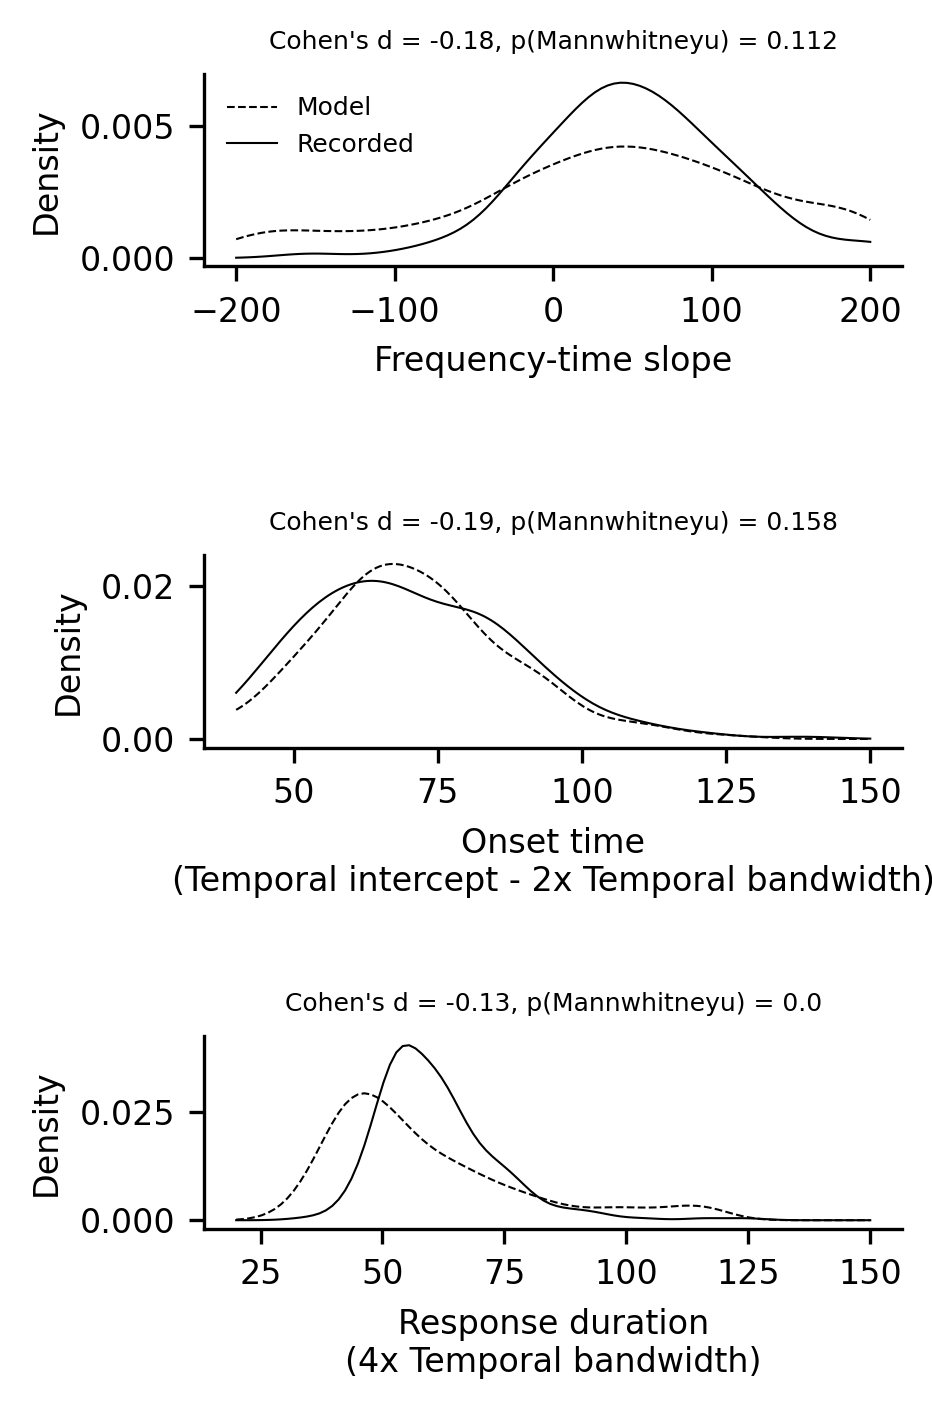

In [ ]:
fig, ax = plt.subplots(3,1, figsize = (3,5))
for i in range(3):
    model_data = tpdist[i]
    invivo_data = tpdist_invivo[i]
    x = domains[i]
    kde_model = gaussian_kde(model_data)
    kde_invivo = gaussian_kde(invivo_data)
    y_model = kde_model.evaluate(x)
    y_invivo = kde_invivo.evaluate(x)
    ax[i].plot(x, y_model, '--', color = 'black', linewidth = linewidth, label = "Model")
    ax[i].plot(x, y_invivo, color = 'black', linewidth = linewidth, label = 'Recorded')
    ax[i].set_title(
        "Cohen's d = "
        + str(cohensd(model_data.astype(np.float32), invivo_data.astype(np.float32)).round(2))
        + ","
        + " p(Mannwhitneyu) = "
        + str(mannwhitneyu(model_data.astype(np.float32), invivo_data.astype(np.float32))[1].round(3))
        , fontsize = 6
    )
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].tick_params(labelsize = 8)
    ax[i].set_xlabel(temporal[i], fontsize = 8)
    ax[i].set_ylabel("Density", fontsize = 8)

fig.subplots_adjust(hspace=1.5)
ax[0].legend(fontsize = 6, frameon = False)

# figname = 'compared_lgn_parameter_dist_single_unit_opt_rds.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)